**Norm-fix rerun** of `wrappers/qwen_analysis/grid/4_loudness_evaluation/probe_accuracy_by_loudness_decile_multiclass.ipynb` (Qwen final norm `1 + w`). Substitutions: `TABLE = Path("/workspace/results/qwen_p2_grid/heldout_multiclass/per_token_scores.csv")` → `TABLE = Path("/workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/per_token_scores.csv")  # score_multiclass_probes_heldout_per_token.sh`; dropped cells [9, 10, 11, 12, 13]

**Figures in the direction notebook's style** (`wrappers/qwen_analysis/4_loudness_evaluation/probe_accuracy_by_loudness_decile.ipynb`): one panel per probe under J-lens loudness, then all MLP probes under each lens, error bars for the trajectory-clustered 95% CI, one colour per arm, one line style per probe family. The statistics are this notebook's own (cells pooled per class, padding excluded), not the direction one's per-row balanced accuracy. The per-class recall grid and the verbalisation control of the original are not drawn here; the per-class recalls are still in `accuracy_by_grid_loudness_decile.csv`.

# Qwen P2 grid: MULTICLASS grid-probe balanced accuracy by grid-loudness decile

The multiclass twin of `./probe_accuracy_by_loudness_decile.ipynb` (the binary one-vs-rest probes), cell for cell:
same held-out rows, same cells, same deciles, same bootstrap, same figures' layout. Held-out 72 (70 gathered). One row per
(trajectory, step, reasoning token): **every** token, so no lens chose the rows. There are 6 multiclass probes:
3 selection arms (jlens / logitlens / random) x {lr, mlp}, all at layer 27 (the Qwen direction profile's J-lens argmax), each predicting a
cell's symbol among A # G _ and `+` padding.

**Input.** `score_probes_per_token.py --probe-type grid_multiclass`, run as recorded in cell 1 (`SCORED_WITH`).
Each row carries the token's cells counted by true class (`n_true_{c}`) and, per probe, how many of each class
it got right (`{probe}_correct_{c}`). It also carries both lenses' **grid** loudness at L27
(`{lens}_grid_logmass_L27`, log P(any pruned-vocabulary grid word)), read from `qwen_p2_heldout_grid_lens`.

**The cells are prepare's.** `grid_multiclass` draws them with `prepare_activations_for_probing._grid_cell_payload`
using the same seed/pad/cap as `prepared/qwen_p2_grid_heldout`, exactly as `grid_binary` does. So these are the rows
`eval_multiclass_probes_heldout.sh` scored, and **cell 2 must reproduce those 6 JSONs**. If it does not, stop.

**Statistics are the repo's.** `stats.bal_acc_from_counts` pools the per-class counts over a bin before dividing:
the mean of pooled recall over the **real** classes A # G _. Padding is excluded: a cell outside the grid says nothing
about the grid, and it is the easy majority of a small grid's cells. So chance is **0.25**, and a token's 25 cells carry
25 cells' weight. The 95% bands resample **trajectory names**, never rows. Deciles come from `stats.qbin` and are re-cut
per lens. `columns.axis_label` names every axis.

**Caveats.** Most grid mass is AXIS (row/column words; `data/jlens/README.md`), so "grid-loud" is largely
"coordinate-loud". A and G are one cell per grid, so their recalls rest on few cells per decile. **Qwen lens outputs before the 2026-09-23 norm fix used the wrong final norm** (`wrappers/qwen_analysis/norm_fix/`): point `LENS_DIR` at the corrected tree before reading these as final.

## 1. Load

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from telos_interp.grid_utils import CELL_SYMBOL_TO_ID
from telos_interp.loudness_analysis import columns as cols
from telos_interp.loudness_analysis import stats

# ---- what this run is ---------------------------------------------------------------
TABLE = Path("/workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/per_token_scores.csv")  # score_multiclass_probes_heldout_per_token.sh
EVAL_JSONS = Path("/workspace/results/qwen_p2_grid/heldout_multiclass")  # eval_multiclass_probes_heldout.sh's output
FIG_DIR = TABLE.parent / "figures"
SIGNAL_JSON = Path("/workspace/repo/interp/data/jlens/qwen/grid_tokens_pruned_qwen3-6-35b-a3b.json")
LAYER = 27
SIGNAL = "grid"
LENSES = ("jlens", "logitlens")
N_DECILES = 10
N_BOOT = 300
SEED = 42
EXCLUDE_RADIUS = 2  # verbalisation control: drop grid words and their +-2 neighbours

SCORED_WITH = """
uv run --extra gpu python telos_interp/loudness_analysis/score_probes_per_token.py \\
    --probe-type grid_multiclass --probe /workspace/probes/qwen_p2_grid/qwen_p2_grid_<arm>_multiclass_l27_<lr|mlp>.pt (x6) \\
    --activations-dir /workspace/activations/qwen_p2_heldout \\
    --lens-dir /workspace/activations/qwen_p2_heldout_grid_lens \\
    --trajectories-dir /workspace/trajectories/qwen3.6-35b/replayed_single_step/heldout_72 \\
    --signal-json /workspace/repo/interp/data/jlens/qwen/grid_tokens_pruned_qwen3-6-35b-a3b.json --signal-name grid \\
    --layer 27 --pad-to-size 15 --max-cells 25 --seed 42 \\
    --cache-activations --cache-dir /workspace/results/qwen_p2_local_belief/heldout/_act_cache \\
    --read-threads 16 --device cuda --out /workspace/results/qwen_p2_grid/heldout_multiclass/per_token_scores.csv
"""

FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

# keep_default_na=False: a decoded token can literally be "NA". Numeric columns are coerced below.
df = pd.read_csv(TABLE, keep_default_na=False, na_values=[""], low_memory=False)
print(f"{len(df):,} token rows, {df['name'].nunique()} trajectories")

# ---- which probes are in the table: discovered from the columns, never hard-coded --------
PROBE_KEYS = sorted(c[: -len("_n_correct")] for c in df.columns if c.endswith("_n_correct"))
KEY_RE = re.compile(r"_(?P<arm>jlens|logitlens|random)_multiclass_l\d+_(?P<mt>lr|mlp)$")
META = {k: KEY_RE.search(k).groupdict() for k in PROBE_KEYS}
ARMS = ["jlens", "logitlens", "random"]
MTYPES = ["lr", "mlp"]
# The real cell classes, by id; padding ('+') is left out of every statistic.
REAL = {CELL_SYMBOL_TO_ID[s]: name for s, name in (("_", "empty"), ("#", "wall"), ("A", "agent"), ("G", "goal"))}
CLASSES = list(REAL.values())
CHANCE = 1.0 / len(REAL)
COUNT_COLS = [f"n_true_{c}" for c in REAL] + [f"{k}_correct_{c}" for k in PROBE_KEYS for c in REAL]
df[COUNT_COLS] = df[COUNT_COLS].apply(pd.to_numeric).astype(np.int64)
COLOR = dict(zip(ARMS, sns.color_palette("colorblind", len(ARMS)), strict=True))
print(f"{len(PROBE_KEYS)} probes: {sorted({m['arm'] for m in META.values()})} x {sorted({m['mt'] for m in META.values()})}")

LOUD = {lens: cols.resolve(df.columns, lens, SIGNAL, LAYER) for lens in LENSES}
for lens, c in LOUD.items():
    df[c] = pd.to_numeric(df[c], errors="coerce")
    print(f"  {lens}: {c}  ({df[c].notna().mean():.1%} of rows have a mass cell)")

1,169,734 token rows, 70 trajectories
6 probes: ['jlens', 'logitlens', 'random'] x ['lr', 'mlp']
  jlens: jlens_grid_logmass_L27  (100.0% of rows have a mass cell)
  logitlens: logitlens_grid_logmass_L27  (100.0% of rows have a mass cell)


## 2. Check: the pooled numbers must reproduce the held-out evaluator

Pool every row, then compare with `eval_grid_probe.py`'s `global` block for the same probe on the same manifest.
Same cells means the **ground truth must match exactly**: every real class's support, and the total cell count.
The **verdicts** may differ by a handful of cells out of ~29M, because the GPU rounds batches of different
shapes slightly differently and a near-tie between two classes can fall either way.

In [2]:
check = []
for k in PROBE_KEYS:
    m = META[k]
    ba, _ = stats.bal_acc_from_counts(df, k, REAL)
    ref = json.loads((EVAL_JSONS / f"{m['arm']}_multiclass_{m['mt']}.json").read_text())["global"]
    pc = ref["per_class"]
    same_truth = all(int(df[f"n_true_{c}"].sum()) == pc[str(c)]["support"] for c in REAL) and int(
        df["n_cells"].astype(int).sum()
    ) == ref["n_rows"]
    flipped = sum(abs(int(df[f"{k}_correct_{c}"].sum()) - pc[str(c)]["correct"]) for c in REAL)
    check.append({**m, "bal_acc": ba, "eval_json": ref["balanced_accuracy_no_padding"],
                  "abs_diff": abs(ba - ref["balanced_accuracy_no_padding"]), "same_truth": same_truth, "cells_flipped": flipped})
check = pd.DataFrame(check)
print(f"ground truth identical for all {len(check)} probes: {bool(check.same_truth.all())}")
print(f"verdicts: max {check.cells_flipped.max()} cell(s) of {df.n_cells.astype(int).sum():,} differ; max |bal_acc diff| = {check.abs_diff.max():.1e}")
assert check.same_truth.all(), "different ROWS from the evaluator -- stop here"
assert check.cells_flipped.max() <= 10 and check.abs_diff.max() < 1e-5, "verdicts differ beyond rounding jitter -- stop here"
check.pivot_table(index="mt", columns="arm", values="bal_acc").round(4)

ground truth identical for all 6 probes: True
verdicts: max 4 cell(s) of 29,243,350 differ; max |bal_acc diff| = 6.3e-08


arm,jlens,logitlens,random
mt,,,
lr,0.2495,0.2570,0.2655
mlp,0.2789,0.2771,0.2933


## 3. Balanced accuracy by loudness decile, per lens

Counts are summed per (trajectory, decile) first. The bootstrap then resamples trajectory names over that small
frame instead of over every row, which gives the same statistic much faster. Every per-class recall is
bootstrapped with the same draws.

In [3]:
def with_decile(frame: pd.DataFrame, lens: str) -> pd.DataFrame:
    d = frame[np.isfinite(frame[LOUD[lens]])].copy()
    d["decile"] = stats.qbin(d[LOUD[lens]], N_DECILES, labels=False).astype(int) + 1
    return d


def pooled(counts: pd.DataFrame, k: str) -> tuple[float, dict]:
    return stats.bal_acc_from_counts(counts, k, REAL)


def decile_table(frame: pd.DataFrame, lens: str) -> pd.DataFrame:
    d = with_decile(frame, lens)
    agg = d.groupby(["decile", "name"])[COUNT_COLS].sum()
    meta = d.groupby("decile").agg(n_tokens=("name", "size"), n_traj=("name", "nunique"), mean_logmass=(LOUD[lens], "mean"))
    rng = np.random.default_rng(SEED)
    names = d["name"].unique()
    draws = [rng.choice(names, size=len(names), replace=True) for _ in range(N_BOOT)]
    rows = []
    for dec, g in agg.groupby(level="decile"):
        g = g.droplevel("decile")
        boot = [g.reindex(pick).fillna(0) for pick in draws]
        for k in PROBE_KEYS:
            ba, rec = pooled(g, k)
            bs = [pooled(b, k) for b in boot]
            row = {"lens": lens, "decile": int(dec), **META[k], "probe_key": k, "bal_acc": ba,
                   "lo": np.nanpercentile([b[0] for b in bs], 2.5), "hi": np.nanpercentile([b[0] for b in bs], 97.5)}
            for c, name in REAL.items():
                r = [b[1].get(c, np.nan) for b in bs]
                row |= {f"recall_{name}": rec.get(c, np.nan),
                        f"recall_{name}_lo": np.nanpercentile(r, 2.5), f"recall_{name}_hi": np.nanpercentile(r, 97.5)}
            rows.append(row | meta.loc[dec].to_dict())
    return pd.DataFrame(rows)


BY_DECILE = pd.concat([decile_table(df, lens) for lens in LENSES], ignore_index=True)
BY_DECILE.to_csv(TABLE.parent / "accuracy_by_grid_loudness_decile.csv", index=False)
print(BY_DECILE[BY_DECILE.lens == "jlens"].drop_duplicates("decile")[["decile", "n_tokens", "n_traj", "mean_logmass"]].to_string(index=False))

 decile  n_tokens  n_traj  mean_logmass
      1  116974.0    70.0    -10.901034
      2  116973.0    70.0     -7.735019
      3  116973.0    70.0     -6.299243
      4  116974.0    70.0     -5.167414
      5  116973.0    70.0     -4.146919
      6  116973.0    70.0     -3.181279
      7  116974.0    70.0     -2.214163
      8  116973.0    70.0     -1.194836
      9  116973.0    70.0     -0.336970
     10  116974.0    70.0     -0.027257


### Loudest minus quietest decile, with a trajectory-clustered 95% CI

The same resampled names are used for both ends, so the CI is on the **gap**, not two independent bands.

In [4]:
def gap_table(frame: pd.DataFrame, lens: str) -> pd.DataFrame:
    d = with_decile(frame, lens)
    ends = d[d.decile.isin([1, N_DECILES])].groupby(["decile", "name"])[COUNT_COLS].sum()
    lo_g, hi_g = ends.loc[1], ends.loc[N_DECILES]
    rng = np.random.default_rng(SEED)
    names = d["name"].unique()
    draws = [rng.choice(names, size=len(names), replace=True) for _ in range(N_BOOT)]
    rows = []
    for k in PROBE_KEYS:
        gap = pooled(hi_g, k)[0] - pooled(lo_g, k)[0]
        bs = np.array([pooled(hi_g.reindex(p).fillna(0), k)[0] - pooled(lo_g.reindex(p).fillna(0), k)[0] for p in draws])
        rows.append({"lens": lens, **META[k], "gap_top_minus_bottom": gap,
                     "lo": np.nanpercentile(bs, 2.5), "hi": np.nanpercentile(bs, 97.5)})
    return pd.DataFrame(rows)


GAPS = pd.concat([gap_table(df, lens) for lens in LENSES], ignore_index=True)
GAPS.to_csv(TABLE.parent / "grid_loudness_gap_top_minus_bottom.csv", index=False)
GAPS.pivot_table(index=["lens", "mt"], columns="arm", values="gap_top_minus_bottom").round(4)

arm             jlens  logitlens  random
lens      mt                            
jlens     lr   0.0343    -0.0072  0.0301
          mlp  0.0337    -0.0022  0.0355
logitlens lr   0.0237     0.0249  0.0241
          mlp  0.0191     0.0305  0.0256

## 4. Figures, direction-notebook style

In [5]:
STYLE = {"lr": "-", "mlp": "--"}
LABEL = {k: f"{m['arm']} {m['mt']}" for k, m in META.items()}
MLP = [k for k in PROBE_KEYS if META[k]["mt"] == "mlp"]


def draw(ax, tab: pd.DataFrame, keys, lens: str) -> None:
    """Loudness decile on x, balanced accuracy on y, with the clustered 95% band."""
    for key in keys:
        t = tab[(tab.probe_key == key) & (tab.lens == lens)].sort_values("decile")
        arm, kind = META[key]["arm"], META[key]["mt"]
        err = np.vstack(
            [
                np.clip(t.bal_acc - t.lo, 0, None).fillna(0),
                np.clip(t.hi - t.bal_acc, 0, None).fillna(0),
            ]
        )
        ax.errorbar(
            t.decile, t.bal_acc, yerr=err, marker="o", ms=4, lw=1.6,
            ls=STYLE.get(kind, "-"), color=COLOR[arm], capsize=2, label=LABEL[key],
        )
    ax.axhline(CHANCE, ls=":", lw=1, color="0.4", label=f"chance ({CHANCE:.2f})")
    ax.set_xlabel(f"{cols.axis_label(lens, SIGNAL, LAYER)} decile\n(1 = quietest, {N_DECILES} = loudest)")
    ax.set_ylabel("Balanced accuracy, A # G _ (cells pooled)")
    ax.set_xticks(sorted(tab.decile.unique()))


def save(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=160)
    print(f"-> {FIG_DIR / f'{name}.png'}")

## 5. One panel per probe (J-lens loudness)

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_jlens_lr.png


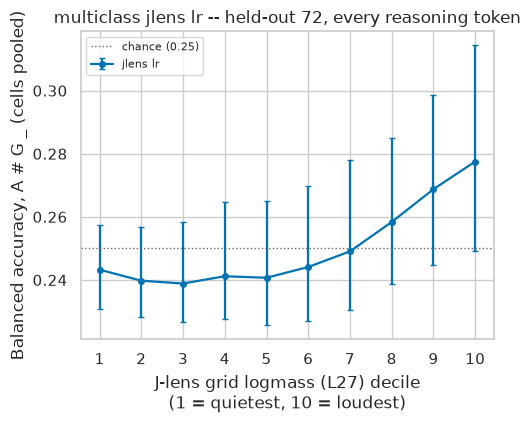

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_jlens_mlp.png


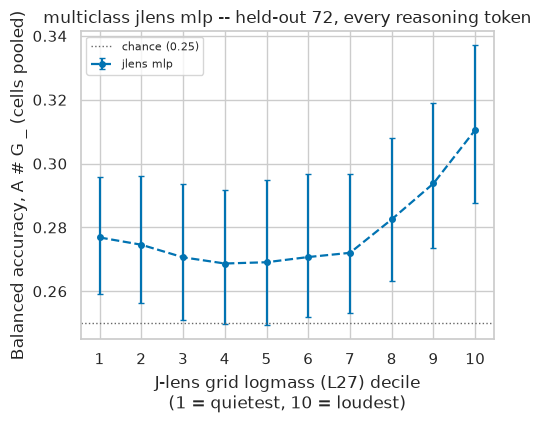

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_logitlens_lr.png


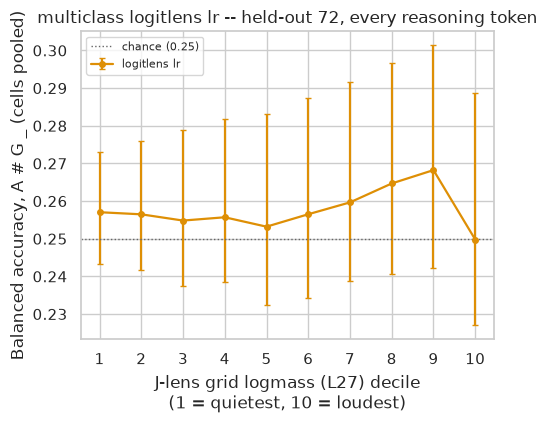

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_logitlens_mlp.png


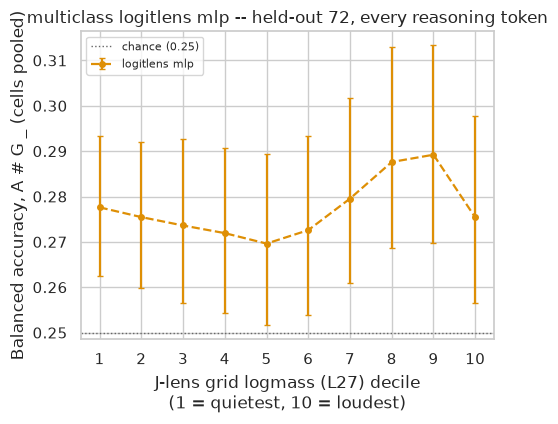

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_random_lr.png


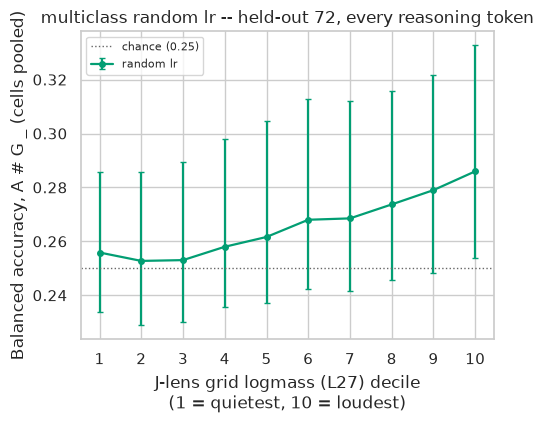

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_random_mlp.png


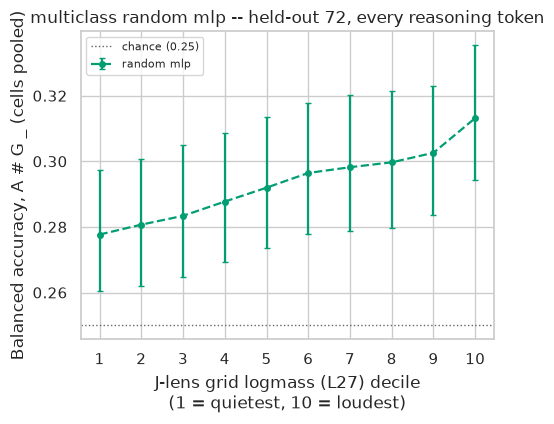

In [6]:
for key in PROBE_KEYS:
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    draw(ax, BY_DECILE, [key], "jlens")
    ax.set_title(f"multiclass {LABEL[key]} -- held-out 72, every reasoning token")
    ax.legend(loc="upper left", fontsize=8)
    save(fig, f"decile_jlens_multiclass_{LABEL[key].replace(' ', '_')}")
    plt.show()

## 6. All MLP probes, J-lens loudness

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_jlens_multiclass_all_mlp.png


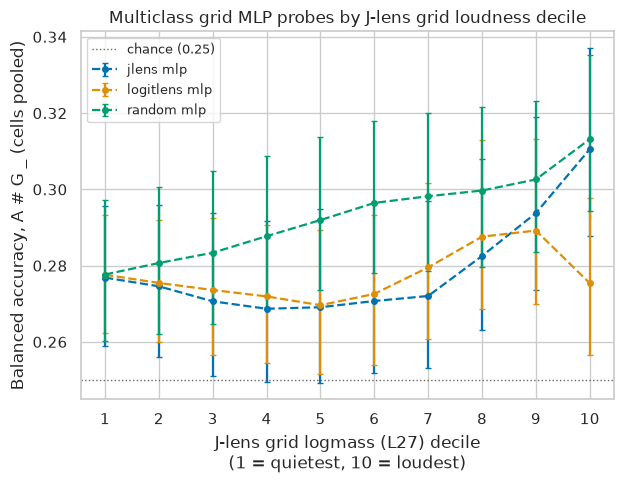

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 5.0))
draw(ax, BY_DECILE, MLP, "jlens")
ax.set_title("Multiclass grid MLP probes by J-lens grid loudness decile")
ax.legend(loc="upper left", fontsize=9)
save(fig, "decile_jlens_multiclass_all_mlp")
plt.show()

## 7. All MLP probes, logitlens loudness

The same rows and probes, re-cut into deciles of **logitlens** loudness; any difference from cell 6 is the ruler.

-> /workspace/results/qwen_p2_grid/heldout_multiclass_fixnorm/figures/decile_logitlens_multiclass_all_mlp.png


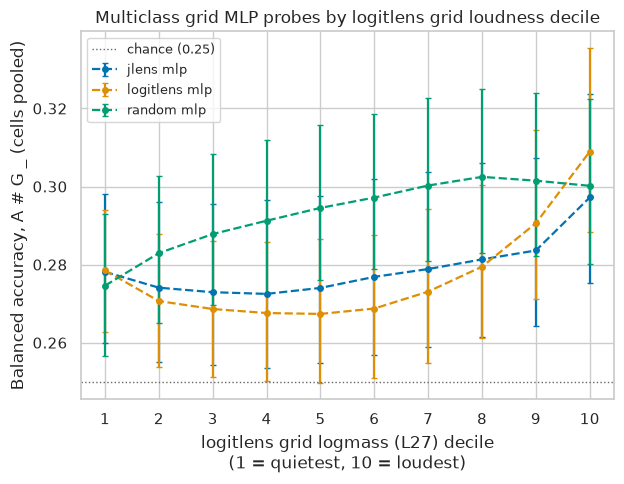

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 5.0))
draw(ax, BY_DECILE, MLP, "logitlens")
ax.set_title("Multiclass grid MLP probes by logitlens grid loudness decile")
ax.legend(loc="upper left", fontsize=9)
save(fig, "decile_logitlens_multiclass_all_mlp")
plt.show()